# Decision Tree Classification Notebook

This notebook contains three classification tasks using DecisionTreeClassifier:
1. Normal classification with make_classification
2. IMDB review classification
3. AG News classification

## Simple Explanation
This notebook teaches Decision Tree classification in very simple steps.
- Part A: Classify normal numeric data made with make_classification.
- Part B-C: Classify IMDB movie reviews (negative or positive).
- Part D: Classify AG News articles into 4 categories.
- You can run each cell from top to bottom.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

np.random.seed(42)
print("Libraries imported successfully")

c:\Users\hamen\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully


## Part A: Normal Classification with make_classification

### Easy Note
make_classification creates artificial data for practice.
The model learns patterns from features and predicts class 0 or class 1.

In [2]:
# Create synthetic classification data
X_num, y_num = make_classification(
    n_samples=2500,
    n_features=20,
    n_informative=10,
    n_redundant=4,
    n_classes=2,
    weights=[0.52, 0.48],
    class_sep=1.2,
    flip_y=0.02,
    random_state=42
)

feature_names = [f"feature_{i}" for i in range(X_num.shape[1])]
df_num = pd.DataFrame(X_num, columns=feature_names)
df_num["target"] = y_num

print("Synthetic dataset shape:", df_num.shape)
print("Class distribution:")
print(df_num["target"].value_counts())
df_num.head()

Synthetic dataset shape: (2500, 21)
Class distribution:
target
0    1287
1    1213
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,2.139176,0.682357,-0.123996,-3.191853,-2.006473,2.093438,-0.133420,-0.456896,2.705206,-0.839561,...,2.023351,3.806326,0.609941,-1.899032,-0.408274,0.083312,-0.610582,-0.476849,-1.361220,0
1,0.946418,0.932523,0.216867,1.652078,0.108133,-4.079870,-3.284705,1.546422,-4.711451,1.286872,...,-3.589953,-2.326500,2.341811,0.811052,1.330890,1.338226,1.379249,-0.575494,-0.475538,1
2,-2.102301,0.007285,-0.795052,0.068554,1.592978,2.124137,0.633626,-2.302792,0.335591,0.545086,...,-1.950578,-0.999894,-1.167977,-0.991626,0.416895,-0.961588,-0.012892,-0.373874,1.618205,1
3,-0.333893,0.085722,0.167059,3.649625,-1.807087,-5.930802,0.508403,-0.773687,-1.997949,0.724747,...,1.585212,4.164588,-1.456811,2.541068,-9.097617,1.783305,0.807978,-0.975140,-3.701382,1
4,0.706524,0.119372,-1.351496,-2.658154,-1.623317,1.101852,-0.246280,-0.321493,1.765757,1.263375,...,1.693726,2.834439,1.631054,-1.195787,0.666471,-0.305952,-0.373210,-0.244114,-1.931278,0


In [3]:
# Train and evaluate Decision Tree on numeric data
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    df_num.drop(columns=["target"]),
    df_num["target"],
    test_size=0.2,
    stratify=df_num["target"],
    random_state=42
)

dt_num = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
dt_num.fit(X_train_num, y_train_num)
y_pred_num = dt_num.predict(X_test_num)

acc_num = accuracy_score(y_test_num, y_pred_num)
prec_num = precision_score(y_test_num, y_pred_num)
rec_num = recall_score(y_test_num, y_pred_num)
f1_num = f1_score(y_test_num, y_pred_num)

print(f"Accuracy : {acc_num:.4f}")
print(f"Precision: {prec_num:.4f}")
print(f"Recall   : {rec_num:.4f}")
print(f"F1-Score : {f1_num:.4f}")

Accuracy : 0.8860
Precision: 0.9189
Recall   : 0.8395
F1-Score : 0.8774


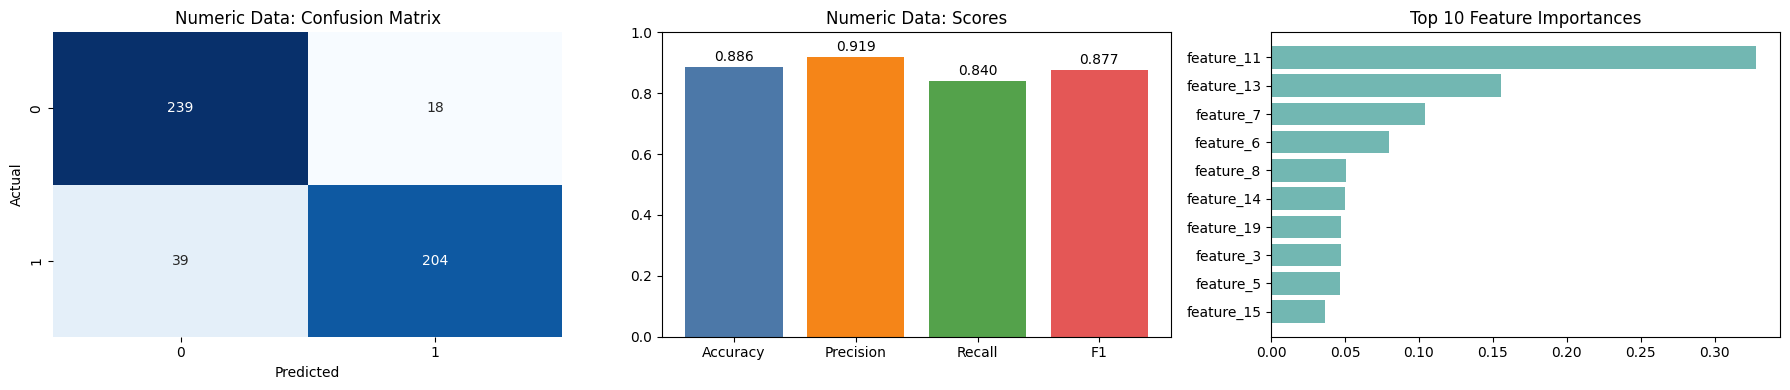

In [4]:
# Visualize numeric classification results
cm_num = confusion_matrix(y_test_num, y_pred_num)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(cm_num, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Numeric Data: Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_scores = [acc_num, prec_num, rec_num, f1_num]
axes[1].bar(metric_names, metric_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Numeric Data: Scores')
for i, v in enumerate(metric_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

importance_df = pd.DataFrame({
    'feature': X_train_num.columns,
    'importance': dt_num.feature_importances_
}).sort_values('importance', ascending=False).head(10)
axes[2].barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#72B7B2')
axes[2].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

## Part B: Load IMDB and AG News Datasets

In [5]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("imdb")

df = pd.DataFrame(dataset["train"])

dataset1 = load_dataset("ag_news")
df1 = pd.DataFrame(dataset1["train"])
df1.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [6]:
print('IMDB train shape:', df.shape)
print('AG News train shape:', df1.shape)
print('IMDB labels:', sorted(df['label'].unique()))
print('AG News labels:', sorted(df1['label'].unique()))

print('IMDB sample:')
print(df[['text', 'label']].head(2))

print('AG News sample:')
print(df1[['text', 'label']].head(2))

IMDB train shape: (25000, 2)
AG News train shape: (120000, 2)
IMDB labels: [np.int64(0), np.int64(1)]
AG News labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
IMDB sample:
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
AG News sample:
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2


## Part C: IMDB Review Classification with Decision Tree

### Easy Note
For IMDB, text must be converted into numbers before training.
TfidfVectorizer does this conversion, then Decision Tree predicts sentiment.

In [7]:
# Use a sampled subset for faster training
imdb_train = pd.DataFrame(dataset['train']).sample(n=6000, random_state=42)
imdb_test = pd.DataFrame(dataset['test']).sample(n=2000, random_state=42)

X_train_imdb = imdb_train['text']
y_train_imdb = imdb_train['label']
X_test_imdb = imdb_test['text']
y_test_imdb = imdb_test['label']

print('IMDB sampled train size:', X_train_imdb.shape[0])
print('IMDB sampled test size :', X_test_imdb.shape[0])

IMDB sampled train size: 6000
IMDB sampled test size : 2000


In [8]:
dt_imdb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=8000, ngram_range=(1, 2), min_df=2)),
    ('model', DecisionTreeClassifier(max_depth=45, min_samples_split=8, min_samples_leaf=2, random_state=42))
])

dt_imdb_pipeline.fit(X_train_imdb, y_train_imdb)
y_pred_imdb = dt_imdb_pipeline.predict(X_test_imdb)

acc_imdb = accuracy_score(y_test_imdb, y_pred_imdb)
prec_imdb = precision_score(y_test_imdb, y_pred_imdb)
rec_imdb = recall_score(y_test_imdb, y_pred_imdb)
f1_imdb = f1_score(y_test_imdb, y_pred_imdb)

print(f'IMDB Accuracy : {acc_imdb:.4f}')
print(f'IMDB Precision: {prec_imdb:.4f}')
print(f'IMDB Recall   : {rec_imdb:.4f}')
print(f'IMDB F1-Score : {f1_imdb:.4f}')

IMDB Accuracy : 0.7025
IMDB Precision: 0.6723
IMDB Recall   : 0.7417
IMDB F1-Score : 0.7053


In [9]:
print('IMDB classification report:')
print(classification_report(y_test_imdb, y_pred_imdb, target_names=['negative', 'positive']))

IMDB classification report:
              precision    recall  f1-score   support

    negative       0.74      0.67      0.70      1040
    positive       0.67      0.74      0.71       960

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.71      0.70      0.70      2000



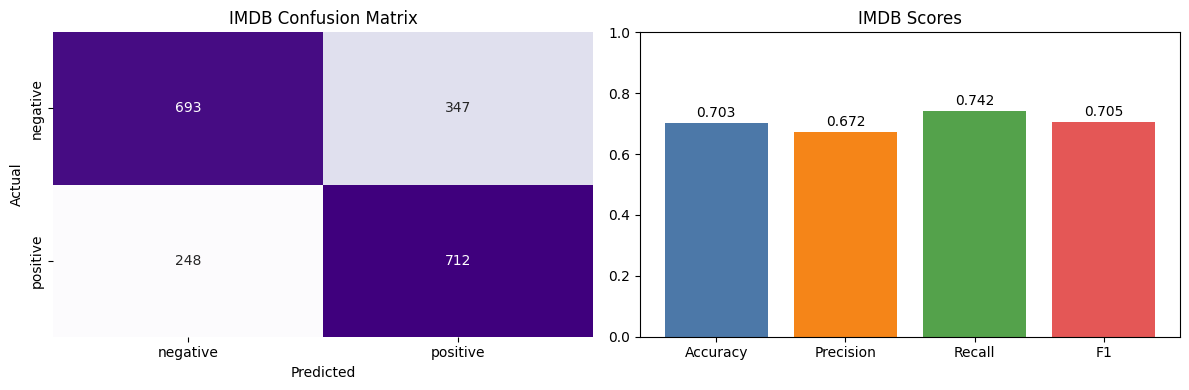

In [10]:
cm_imdb = confusion_matrix(y_test_imdb, y_pred_imdb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_imdb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0])
axes[0].set_title('IMDB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['negative', 'positive'])
axes[0].set_yticklabels(['negative', 'positive'])

imdb_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
imdb_scores = [acc_imdb, prec_imdb, rec_imdb, f1_imdb]
axes[1].bar(imdb_metrics, imdb_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('IMDB Scores')
for i, v in enumerate(imdb_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Part D: AG News Classification with Decision Tree

### Easy Note
AG News is a 4-class problem (World, Sports, Business, Sci/Tech).
The model predicts which class a new news sentence belongs to.

In [11]:
ag_train = pd.DataFrame(dataset1['train']).sample(n=12000, random_state=42)
ag_test = pd.DataFrame(dataset1['test']).sample(n=3000, random_state=42)

X_train_ag = ag_train['text']
y_train_ag = ag_train['label']
X_test_ag = ag_test['text']
y_test_ag = ag_test['label']

class_names_ag = dataset1['train'].features['label'].names
print('AG sampled train size:', X_train_ag.shape[0])
print('AG sampled test size :', X_test_ag.shape[0])
print('AG classes:', class_names_ag)

AG sampled train size: 12000
AG sampled test size : 3000
AG classes: ['World', 'Sports', 'Business', 'Sci/Tech']


In [12]:
dt_ag_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2), min_df=3)),
    ('model', DecisionTreeClassifier(max_depth=60, min_samples_split=12, min_samples_leaf=2, random_state=42))
])

dt_ag_pipeline.fit(X_train_ag, y_train_ag)
y_pred_ag = dt_ag_pipeline.predict(X_test_ag)

acc_ag = accuracy_score(y_test_ag, y_pred_ag)
prec_ag = precision_score(y_test_ag, y_pred_ag, average='weighted')
rec_ag = recall_score(y_test_ag, y_pred_ag, average='weighted')
f1_ag = f1_score(y_test_ag, y_pred_ag, average='weighted')

print(f'AG News Accuracy : {acc_ag:.4f}')
print(f'AG News Precision: {prec_ag:.4f}')
print(f'AG News Recall   : {rec_ag:.4f}')
print(f'AG News F1-Score : {f1_ag:.4f}')

AG News Accuracy : 0.6730
AG News Precision: 0.7129
AG News Recall   : 0.6730
AG News F1-Score : 0.6734


In [13]:
print('AG News classification report:')
print(classification_report(y_test_ag, y_pred_ag, target_names=class_names_ag))

AG News classification report:
              precision    recall  f1-score   support

       World       0.53      0.84      0.65       759
      Sports       0.77      0.75      0.76       743
    Business       0.71      0.57      0.63       713
    Sci/Tech       0.84      0.54      0.66       785

    accuracy                           0.67      3000
   macro avg       0.71      0.67      0.67      3000
weighted avg       0.71      0.67      0.67      3000



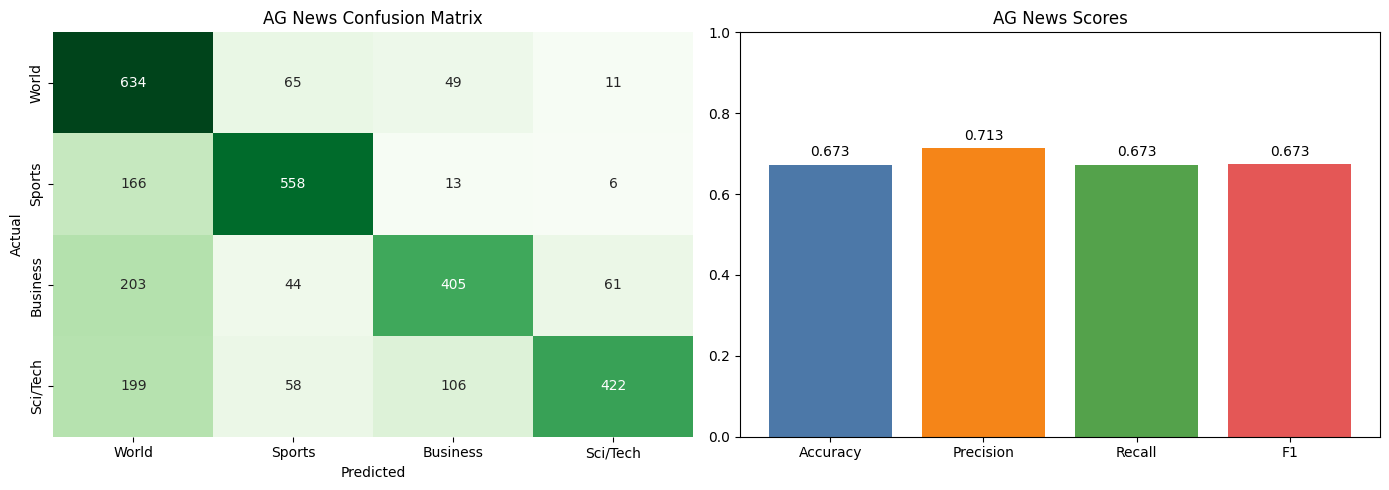

In [14]:
cm_ag = confusion_matrix(y_test_ag, y_pred_ag, labels=list(range(len(class_names_ag))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_ag, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=class_names_ag, yticklabels=class_names_ag)
axes[0].set_title('AG News Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

ag_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
ag_scores = [acc_ag, prec_ag, rec_ag, f1_ag]
axes[1].bar(ag_metrics, ag_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('AG News Scores')
for i, v in enumerate(ag_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Summary

You trained Decision Tree classifiers on:
- Numeric synthetic data from make_classification
- IMDB text reviews
- AG News text articles

If training is slow on your machine, reduce sample size or max_features in TfidfVectorizer.

In [15]:
# New data prediction examples
print('--- New Data Predictions (Decision Tree) ---')

# 1) Numeric sample prediction
new_numeric_sample = X_test_num.iloc[[0]].copy()
numeric_pred = dt_num.predict(new_numeric_sample)[0]
print('Numeric sample predicted class:', int(numeric_pred))

# 2) New IMDB review prediction
new_imdb_review = "This movie was wonderful, emotional, and beautifully acted."
imdb_pred = dt_imdb_pipeline.predict([new_imdb_review])[0]
imdb_label = 'positive' if imdb_pred == 1 else 'negative'
print('IMDB review prediction:', imdb_label)

# 3) New AG News prediction
new_ag_text = "The central bank announced a new interest rate policy for inflation control."
ag_pred = dt_ag_pipeline.predict([new_ag_text])[0]
print('AG News prediction:', class_names_ag[ag_pred])

--- New Data Predictions (Decision Tree) ---
Numeric sample predicted class: 0
IMDB review prediction: positive
AG News prediction: World
